In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import LeaveOneOut
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# Loading

In [2]:
# load the Titanic dataset
titanic = pd.read_csv("titanic.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# drop columns "PassengerId", "Name", "Ticket", "Cabin"
titanic = titanic.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])
titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


We will not do pre-processing before splitting the data into train and test sets, since we want to avoid data leakage.

# Train test

In [7]:
# split the data into training and testing sets
X = titanic.drop(columns=["Survived"])
y = titanic["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# count data points in train and test sets
print(f"Number of data points in training set: {len(X_train)}")
print(f"Number of data points in test set: {len(X_test)}")

Number of data points in training set: 712
Number of data points in test set: 179


In [9]:
# check the distribution of the target variable in the train and test sets
print("Distribution of target variable in training set:")
print(y_train.value_counts(normalize=True))
print("\nDistribution of target variable in test set:")
print(y_test.value_counts(normalize=True))

Distribution of target variable in training set:
Survived
0    0.623596
1    0.376404
Name: proportion, dtype: float64

Distribution of target variable in test set:
Survived
0    0.586592
1    0.413408
Name: proportion, dtype: float64


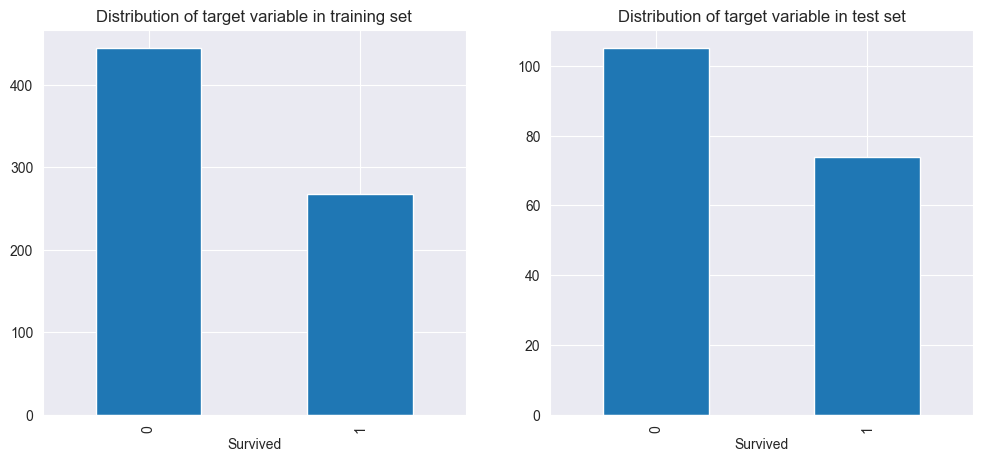

In [10]:
# visualize the distribution of the target variable in the train and test sets
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
y_train.value_counts().plot(kind="bar")
plt.title("Distribution of target variable in training set")
plt.subplot(1, 2, 2)
y_test.value_counts().plot(kind="bar")
plt.title("Distribution of target variable in test set")
plt.show()

# Train val test

In [13]:
# split the data into training and testing sets
X = titanic.drop(columns=["Survived"])
y = titanic["Survived"]
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

In [14]:
# count data points in train, val and test sets
print(f"Number of data points in training set: {len(X_train_val)}")
print(f"Number of data points in validation set: {len(X_val)}")
print(f"Number of data points in test set: {len(X_test)}")

Number of data points in training set: 712
Number of data points in validation set: 143
Number of data points in test set: 179


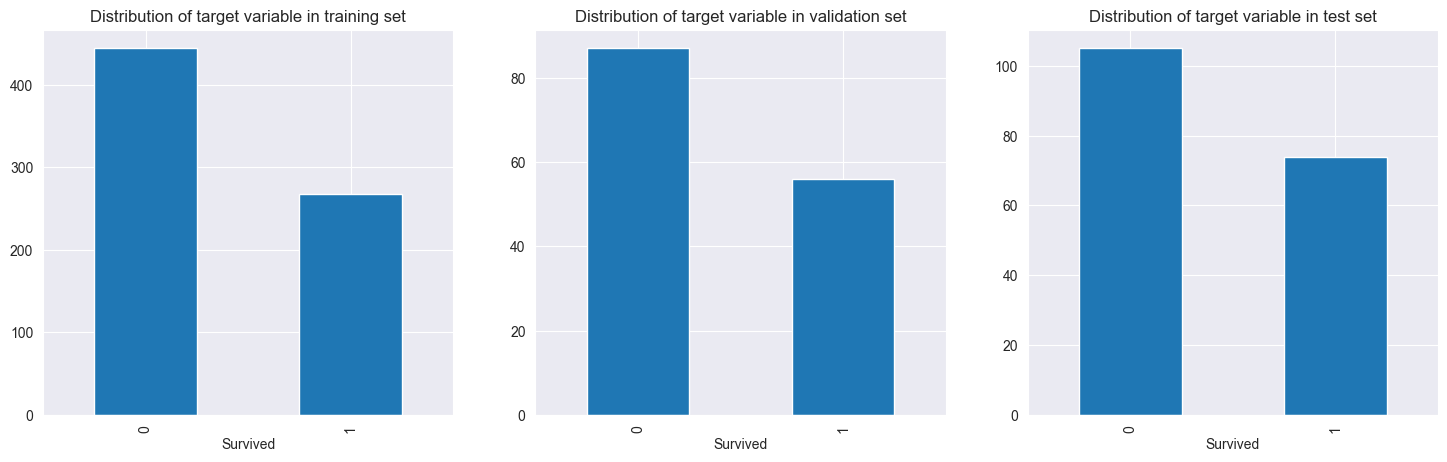

In [15]:
# plot the distribution of the target variable in the train, val and test sets
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
y_train_val.value_counts().plot(kind="bar")
plt.title("Distribution of target variable in training set")
plt.subplot(1, 3, 2)
y_val.value_counts().plot(kind="bar")
plt.title("Distribution of target variable in validation set")
plt.subplot(1, 3, 3)
y_test.value_counts().plot(kind="bar")
plt.title("Distribution of target variable in test set")
plt.show()

In [21]:
# train a decision tree classifier on the training set
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [22]:
# evaluate the model on the validation set
val_accuracy = tree_clf.score(X_val, y_val)
print(f"Validation set accuracy: {val_accuracy:.2f}")
train_accuracy = tree_clf.score(X_train, y_train)
print(f"Train set accuracy: {train_accuracy:.2f}")

Validation set accuracy: 0.75
Train set accuracy: 0.98


In [23]:
# overfitting: update hyperparameters to control the complexity of the tree
tree_clf_pruned = DecisionTreeClassifier(max_depth=4, min_samples_split=5, random_state=42)
tree_clf_pruned.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [24]:
# evaluate the pruned tree on the validation set and compare with the train set accuracy
val_accuracy_pruned = tree_clf_pruned.score(X_val, y_val)
print(f"Validation set accuracy of pruned tree: {val_accuracy_pruned:.2f}")
train_accuracy_pruned = tree_clf_pruned.score(X_train, y_train)
print(f"Train set accuracy of pruned tree: {train_accuracy_pruned:.2f}")

Validation set accuracy of pruned tree: 0.83
Train set accuracy of pruned tree: 0.84


In [25]:
# evaluate the pruned tree on the test set
test_accuracy_pruned = tree_clf_pruned.score(X_test, y_test)
print(f"Test set accuracy of pruned tree: {test_accuracy_pruned:.2f}")

Test set accuracy of pruned tree: 0.80


After I evaluate on the test set, I am done and do not go back to the training set to update the model. The test set is only used **once** at the very end, after I have selected the final model using the validation set. If I go back to the training set and update the model after evaluating on the test set, I will be indirectly using the test set to train the model, which will lead to data leakage and an overestimation of the model's performance on unseen data.

# Cross validation

In [41]:
# split the data using croos validation
X = titanic.drop(columns=["Survived"])
y = titanic["Survived"]
# split the data into training and testing sets before cross validation to avoid data leakage
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tree_clf = DecisionTreeClassifier(max_depth=4, min_samples_split=5, random_state=42)
cv_scores = cross_val_score(tree_clf, X_train_val, y_train_val, cv=5)
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean cross-validation score: {cv_scores.mean():.2f}")

Cross-validation scores: [0.8041958  0.82517483 0.78169014 0.77464789 0.83098592]
Mean cross-validation score: 0.80


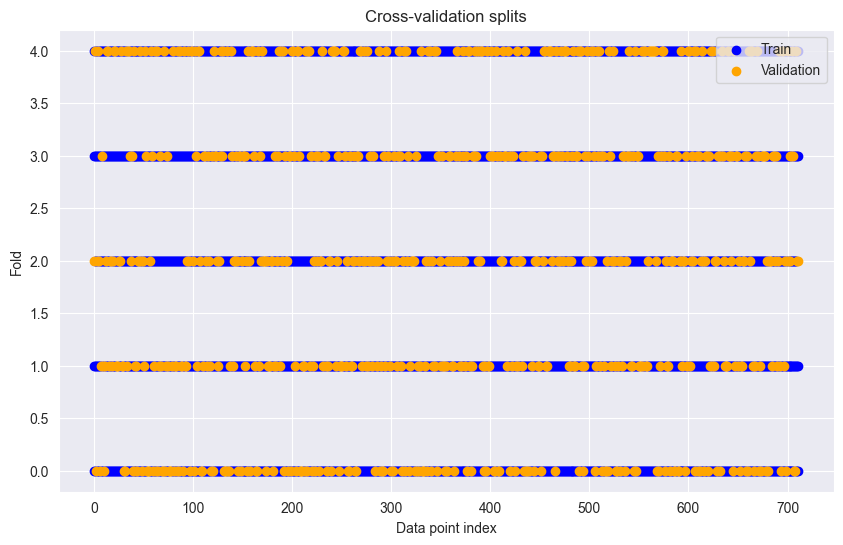

In [42]:
# visualize the cross-validation splits of data
kf = KFold(n_splits=5, shuffle=True, random_state=42) # if shuffle=False, the splits will be the same in each fold
plt.figure(figsize=(10, 6))
for fold, (train_index, val_index) in enumerate(kf.split(X_train_val)):
    plt.scatter(train_index, [fold] * len(train_index), color="blue", label="Train" if fold == 0 else "")
    plt.scatter(val_index, [fold] * len(val_index), color="orange", label="Validation" if fold == 0 else "")
plt.xlabel("Data point index")
plt.ylabel("Fold")
plt.title("Cross-validation splits")
plt.legend()
plt.show()

In [43]:
# evaluate the model on the test set
tree_clf.fit(X_train_val, y_train_val)
test_accuracy_cv = tree_clf.score(X_test, y_test)
print(f"Test set accuracy after cross-validation: {test_accuracy_cv:.2f}")

Test set accuracy after cross-validation: 0.80


# Leave-one-out cross validation (LOOCV)

In [44]:
# only consider the first 100 data points to avoid long computation time
X_small = X_train_val.iloc[:100]
y_small = y_train_val.iloc[:100]

# split the data into train and test sets before LOOCV to avoid data leakage
X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(X_small, y_small, test_size=0.2, random_state=42)
loo = LeaveOneOut()
loo_scores = cross_val_score(tree_clf, X_train_small, y_train_small, cv=loo)
print(f"LOOCV scores: {loo_scores}")
print(f"Mean LOOCV score: {loo_scores.mean():.2f}")

LOOCV scores: [1. 0. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 1. 0. 1.
 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1.
 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 0. 1. 1. 1. 0. 0. 1. 1.]
Mean LOOCV score: 0.78


In [45]:
# evaluate the model on the test set after LOOCV
tree_clf.fit(X_train_small, y_train_small)
test_accuracy_loo = tree_clf.score(X_test_small, y_test_small)
print(f"Test set accuracy after LOOCV: {test_accuracy_loo:.2f}")

Test set accuracy after LOOCV: 0.70


# Stratification

In [56]:
# show the distribution of the target variable in the original dataset
print("Distribution of target variable in original dataset:")
print(y.value_counts(normalize=True))

Distribution of target variable in original dataset:
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [57]:
# split the data into training and testing sets with stratification to maintain the distribution of the target variable
X_train_strat, X_test_strat, y_train_strat, y_test_strat = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# check the distribution of the target variable in the train and test sets after stratification
print("Distribution of target variable in training set after stratification:")
print(y_train_strat.value_counts(normalize=True))
print("\nDistribution of target variable in test set after stratification:")
print(y_test_strat.value_counts(normalize=True))

Distribution of target variable in training set after stratification:
Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Distribution of target variable in test set after stratification:
Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64
